# FhEFL — Comprehensive Results Notebook
Publications-quality figures for IEEE Transactions on Artificial Intelligence

In [12]:
import ast, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── IEEE journal style ──────────────────────────────────────────
rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "legend.framealpha": 0.9,
    "lines.linewidth": 1.4,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

RESULTS_DIR = "."   # run from FedAvg/results/
PLOTS_DIR   = "./plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Method registry ─────────────────────────────────────────────
METHODS = {
    "FedAvg":        {"dir": "fedAvg",  "color": "#ff7f0e", "ls": "--", "lw": 1, "marker": "s"},
    "Trimmed-Mean":  {"dir": "mean",    "color": "#2ca02c", "ls": "-.", "lw": 1, "marker": "^"},
    "Median":        {"dir": "median",  "color": "#d62728", "ls": ":",  "lw": 1, "marker": "D"},
    "KRUM":          {"dir": "krum",    "color": "#9467bd", "ls": "--", "lw": 1, "marker": "v"},
    "FLTrust":       {"dir": "fltrust", "color": "#8c564b", "ls": "-.", "lw": 1, "marker": "p"},
    "DP-FL":         {"dir": "dp_fl",   "color": "#e377c2", "ls": ":",  "lw": 1, "marker": "h"},
    "BREA":          {"dir": "brea",    "color": "#7f7f7f", "ls": "--", "lw": 1, "marker": "*"},
    "RSA":           {"dir": "rsa",     "color": "#bcbd22", "ls": "-",  "lw": 1, "marker": "x"},
    "FhEFL (Ours)": {"dir": "e_d",     "color": "#1f77b4", "ls": "-",  "lw": 2.2, "marker": "o"}
}

def load(method_dir, filename):
    """Load a result list; return None if file missing or empty."""
    path = os.path.join(RESULTS_DIR, method_dir, filename)
    if not os.path.exists(path):
        return None
    try:
        data = ast.literal_eval(open(path).read().strip())
        return [float(v) * 100 for v in data] if data else None
    except Exception:
        return None

def smooth(data, w=5):
    """Simple moving-average smoothing."""
    if len(data) < w:
        return data
    kernel = np.ones(w) / w
    pad = np.pad(data, (w//2, w//2), mode="edge")
    return np.convolve(pad, kernel, mode="valid")[:len(data)]

print("Setup complete. Methods:", list(METHODS.keys()))


Setup complete. Methods: ['FedAvg', 'Trimmed-Mean', 'Median', 'KRUM', 'FLTrust', 'DP-FL', 'BREA', 'RSA', 'FhEFL (Ours)']


## 1  Helper functions

In [13]:
def plot_panel(ax, dataset, n_attackers, metric, attack_suffix="",
               methods=None, every=10, do_smooth=True, ylim=None):
    """Plot one panel (one dataset / attacker count combination)."""
    if methods is None:
        methods = list(METHODS.keys())
    filename = f"{metric}_{dataset}_{n_attackers}{attack_suffix}.txt"
    plotted = []
    for name in methods:
        cfg = METHODS[name]
        data = load(cfg["dir"], filename)
        if data is None:
            continue
        xs = list(range(1, len(data) + 1))
        ys = smooth(data) if do_smooth else data
        ax.plot(xs, ys, color=cfg["color"], ls=cfg["ls"], lw=cfg["lw"],
                label=name, markevery=every, marker=cfg["marker"],
                markersize=4, markeredgewidth=0.6)
        plotted.append(name)
    ax.set_xlabel("Communication Round")
    if metric == "accuracy":
        ax.set_ylabel("Test Accuracy (%)")
        if ylim: ax.set_ylim(ylim)
    else:
        ax.set_ylabel("Attack Success Rate (%)")
    return plotted

DATASET_LABELS = {"mnist": "MNIST", "cifar": "CIFAR-10", "cifar-100": "CIFAR-100"}


## 2  Accuracy comparison — Label-Flipping Attack (20 attackers)

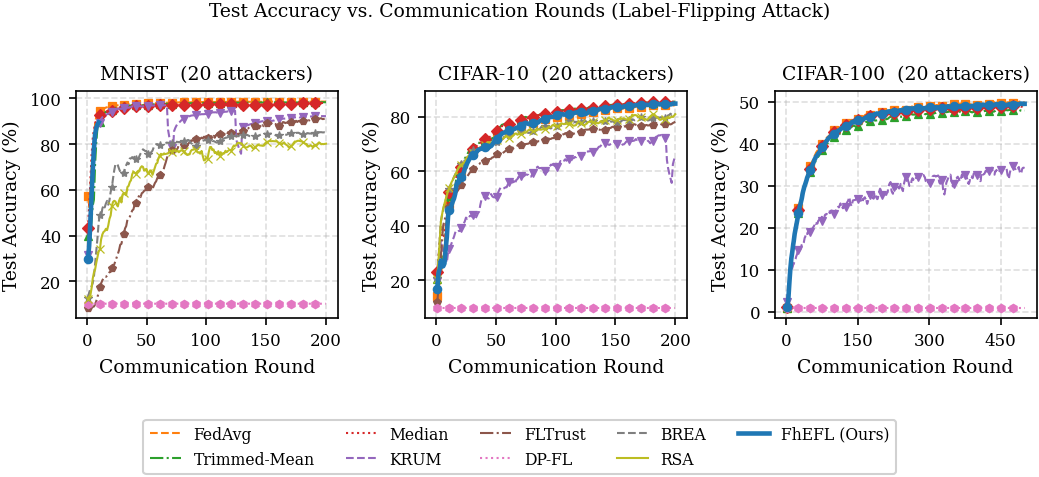

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(7.16, 2.6), sharey=False)
configs = [("mnist", 20, 200), ("cifar", 20, 200), ("cifar-100", 20, 500)]

for ax, (ds, na, ep) in zip(axs, configs):
    plotted = plot_panel(ax, ds, na, "accuracy", every=max(1, ep//20))
    ax.set_title(f"{DATASET_LABELS[ds]}  ({na} attackers)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))

# Shared legend below the figure
handles = [Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                  lw=METHODS[n]["lw"], label=n) for n in METHODS if n in plotted or True]
fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.22),
           frameon=True, handlelength=2)
fig.suptitle("Test Accuracy vs. Communication Rounds (Label-Flipping Attack)", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_accuracy_label_flipping_20.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_accuracy_label_flipping_20.png")
plt.show()


## 3  Attack Success Rate — Label-Flipping (20 attackers)

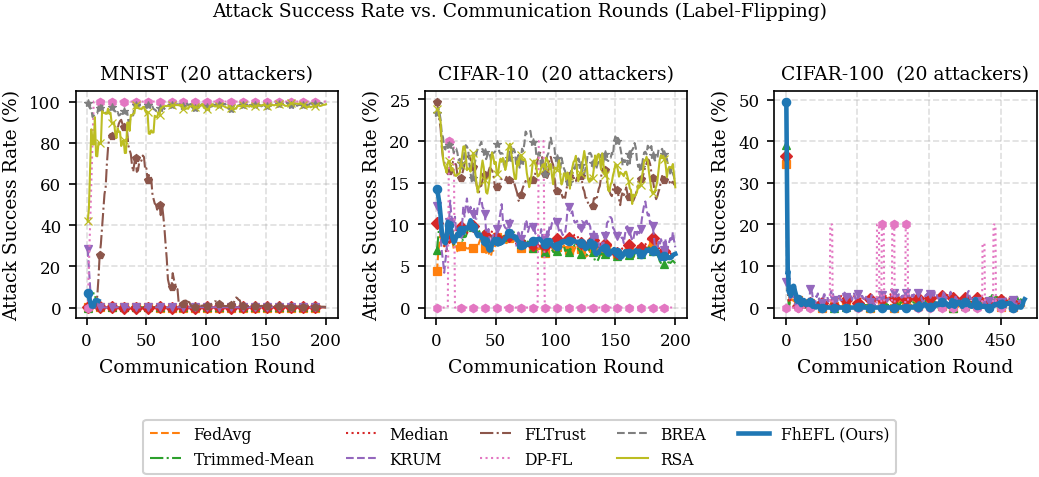

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(7.16, 2.6))
configs = [("mnist", 20, 200), ("cifar", 20, 200), ("cifar-100", 20, 500)]

for ax, (ds, na, ep) in zip(axs, configs):
    plot_panel(ax, ds, na, "asr", every=max(1, ep//20))
    ax.set_title(f"{DATASET_LABELS[ds]}  ({na} attackers)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.22),
           frameon=True, handlelength=2)
fig.suptitle("Attack Success Rate vs. Communication Rounds (Label-Flipping)", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_asr_label_flipping_20.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_asr_label_flipping_20.png")
plt.show()


## 4  Effect of Number of Attackers (MNIST)

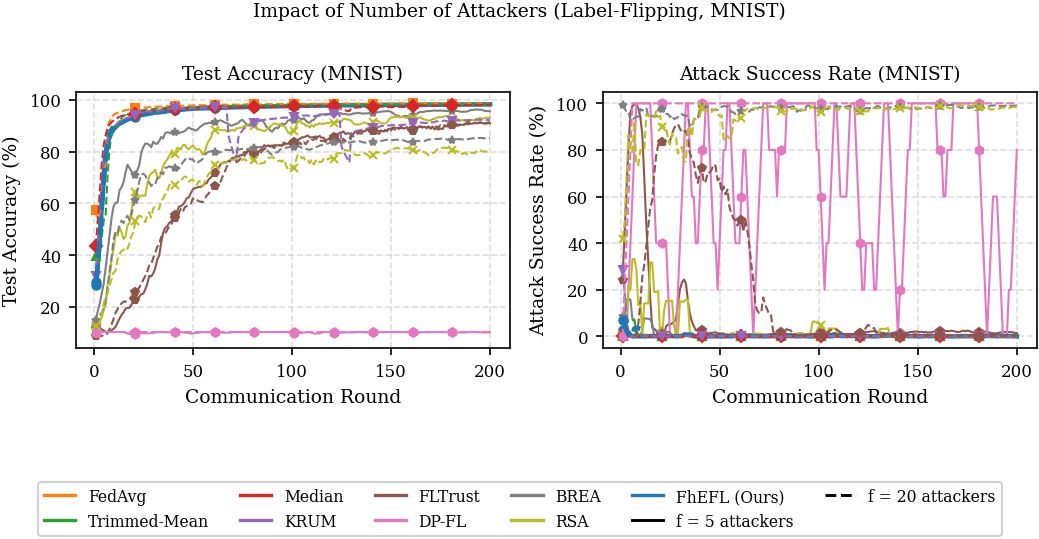

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(7.16, 2.8))
ATTACKER_COUNTS = [5, 20]
ax_acc, ax_asr = axs

for count, ls_override in zip(ATTACKER_COUNTS, ["-", "--"]):
    for name, cfg in METHODS.items():
        acc = load(cfg["dir"], f"accuracy_mnist_{count}.txt")
        if acc is None:
            continue
        xs = list(range(1, len(acc)+1))
        label = f"{name} (f={count})"
        ax_acc.plot(xs, smooth(acc), color=cfg["color"], ls=ls_override,
                    lw=cfg["lw"], label=label, marker=cfg["marker"],
                    markevery=20, markersize=4)

for count, ls_override in zip(ATTACKER_COUNTS, ["-", "--"]):
    for name, cfg in METHODS.items():
        asr = load(cfg["dir"], f"asr_mnist_{count}.txt")
        if asr is None:
            continue
        xs = list(range(1, len(asr)+1))
        ax_asr.plot(xs, smooth(asr), color=cfg["color"], ls=ls_override,
                    lw=cfg["lw"], marker=cfg["marker"],
                    markevery=20, markersize=4)

ax_acc.set_xlabel("Communication Round"); ax_acc.set_ylabel("Test Accuracy (%)")
ax_acc.set_title("Test Accuracy (MNIST)")
ax_asr.set_xlabel("Communication Round"); ax_asr.set_ylabel("Attack Success Rate (%)")
ax_asr.set_title("Attack Success Rate (MNIST)")

# Custom legend: solid=5, dashed=20 attackers
from matplotlib.patches import Patch
legend_entries = (
    [Line2D([0],[0], color=METHODS[n]["color"], lw=1.6, label=n) for n in METHODS]
  + [Line2D([0],[0], color="k", ls="-",  lw=1.4, label="f = 5 attackers"),
     Line2D([0],[0], color="k", ls="--", lw=1.4, label="f = 20 attackers")]
)
fig.legend(handles=legend_entries, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.28), frameon=True, handlelength=2)
fig.suptitle("Impact of Number of Attackers (Label-Flipping, MNIST)", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_attacker_count_mnist.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_attacker_count_mnist.png")
plt.show()


## 5  Model Poisoning Attack Comparison

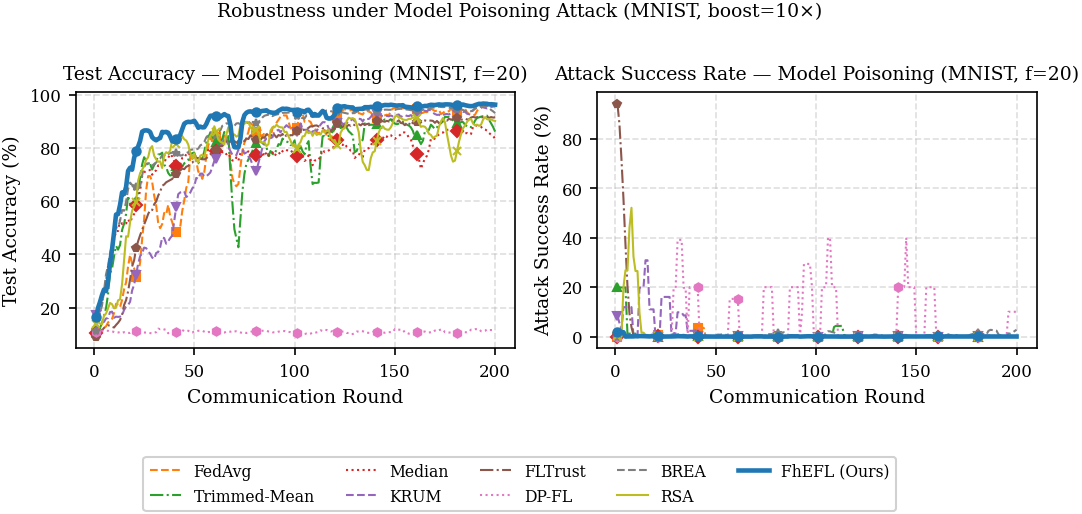

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(7.16, 2.8))
ax_acc, ax_asr = axs

for name, cfg in METHODS.items():
    acc = load(cfg["dir"], "accuracy_mnist_20_model_poisoning.txt")
    if acc is None: continue
    ax_acc.plot(range(1, len(acc)+1), smooth(acc), color=cfg["color"],
                ls=cfg["ls"], lw=cfg["lw"], label=name,
                marker=cfg["marker"], markevery=20, markersize=4)

for name, cfg in METHODS.items():
    asr = load(cfg["dir"], "asr_mnist_20_model_poisoning.txt")
    if asr is None: continue
    ax_asr.plot(range(1, len(asr)+1), smooth(asr), color=cfg["color"],
                ls=cfg["ls"], lw=cfg["lw"], label=name,
                marker=cfg["marker"], markevery=20, markersize=4)

ax_acc.set_xlabel("Communication Round"); ax_acc.set_ylabel("Test Accuracy (%)")
ax_acc.set_title("Test Accuracy — Model Poisoning (MNIST, f=20)")
ax_asr.set_xlabel("Communication Round"); ax_asr.set_ylabel("Attack Success Rate (%)")
ax_asr.set_title("Attack Success Rate — Model Poisoning (MNIST, f=20)")

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.22), frameon=True)
fig.suptitle("Robustness under Model Poisoning Attack (MNIST, boost=10×)", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_model_poisoning_mnist.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_model_poisoning_mnist.png")
plt.show()


## 6  Final Accuracy & ASR Bar Chart (all datasets)

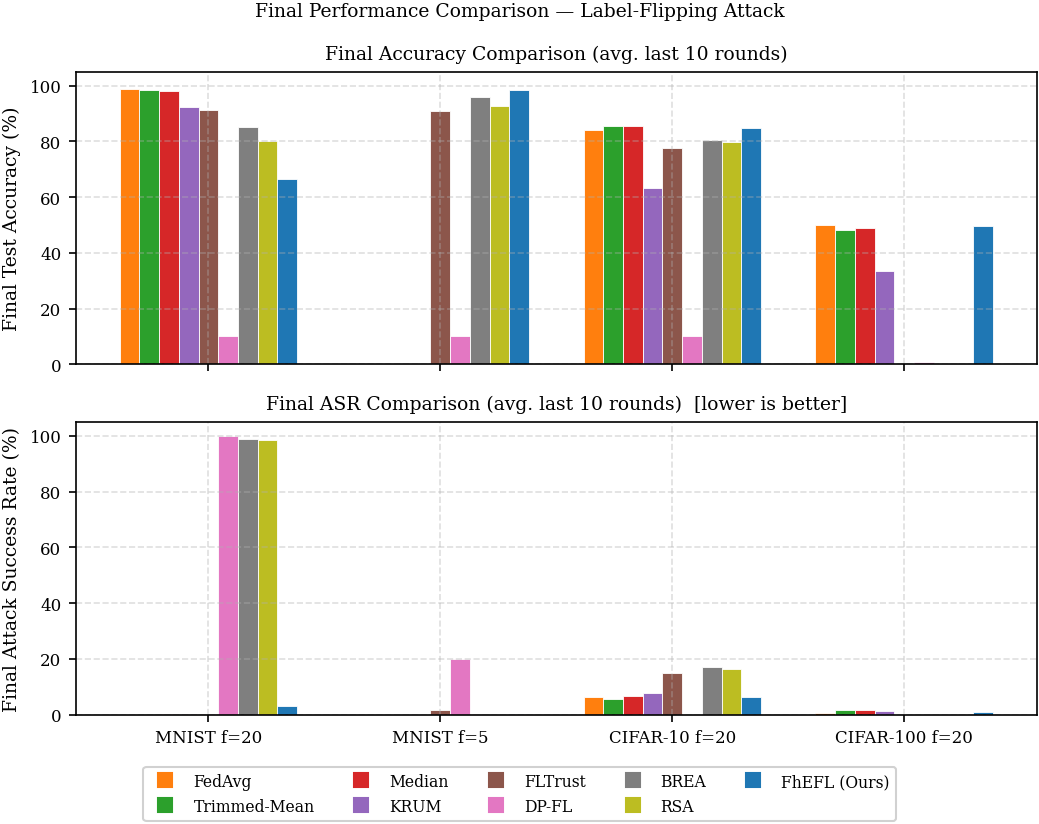

Note: missing bars = experiments not yet complete.


In [18]:
def final_val(method_dir, filename, last_n=10):
    data = load(method_dir, filename)
    if data is None:
        return float("nan")
    return float(np.mean(data[-last_n:]))

# ── config: (x-label, accuracy file, ASR file) ─────────────────
EVAL_CONFIGS = [
    ("MNIST f=20",     "accuracy_mnist_20.txt",      "asr_mnist_20.txt"),
    ("MNIST f=5",      "accuracy_mnist_5.txt",       "asr_mnist_5.txt"),
    ("CIFAR-10 f=20",  "accuracy_cifar_20.txt",      "asr_cifar_20.txt"),
    ("CIFAR-100 f=20", "accuracy_cifar-100_20.txt",  "asr_cifar-100_20.txt"),
]

n_methods = len(METHODS)
n_configs = len(EVAL_CONFIGS)
x = np.arange(n_configs)
bar_w = 0.085
offsets = np.linspace(-(n_methods - 1) * bar_w / 2,
                       (n_methods - 1) * bar_w / 2, n_methods)

fig, (ax_acc, ax_asr) = plt.subplots(2, 1, figsize=(7.16, 5.2), sharex=True)

for i, (name, cfg) in enumerate(METHODS.items()):
    acc_vals = [final_val(cfg["dir"], acc_f) for _, acc_f, _ in EVAL_CONFIGS]
    asr_vals = [final_val(cfg["dir"], asr_f) for _, _, asr_f in EVAL_CONFIGS]
    pos = x + offsets[i]
    for j, (av, sv) in enumerate(zip(acc_vals, asr_vals)):
        # skip NaN bars — experiments may still be running
        if not np.isnan(av):
            ax_acc.bar(pos[j], av, bar_w, color=cfg["color"],
                       edgecolor="white", linewidth=0.4,
                       label=name if j == 0 else "_")
        if not np.isnan(sv):
            ax_asr.bar(pos[j], sv, bar_w, color=cfg["color"],
                       edgecolor="white", linewidth=0.4)

ax_acc.set_ylabel("Final Test Accuracy (%)")
ax_acc.set_title("Final Accuracy Comparison (avg. last 10 rounds)")
ax_acc.set_ylim(0, 105)
ax_asr.set_ylabel("Final Attack Success Rate (%)")
ax_asr.set_title("Final ASR Comparison (avg. last 10 rounds)  [lower is better]")
ax_asr.set_ylim(0, 105)
ax_asr.set_xticks(x)
ax_asr.set_xticklabels([c[0] for c in EVAL_CONFIGS], rotation=0)

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"],
                            marker="s", markersize=7, ls="", label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)
fig.suptitle("Final Performance Comparison — Label-Flipping Attack", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_bar_final_accuracy_asr.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_bar_final_accuracy_asr.png")
plt.show()
print("Note: missing bars = experiments not yet complete.")


## 7  CIFAR-10 Accuracy & ASR

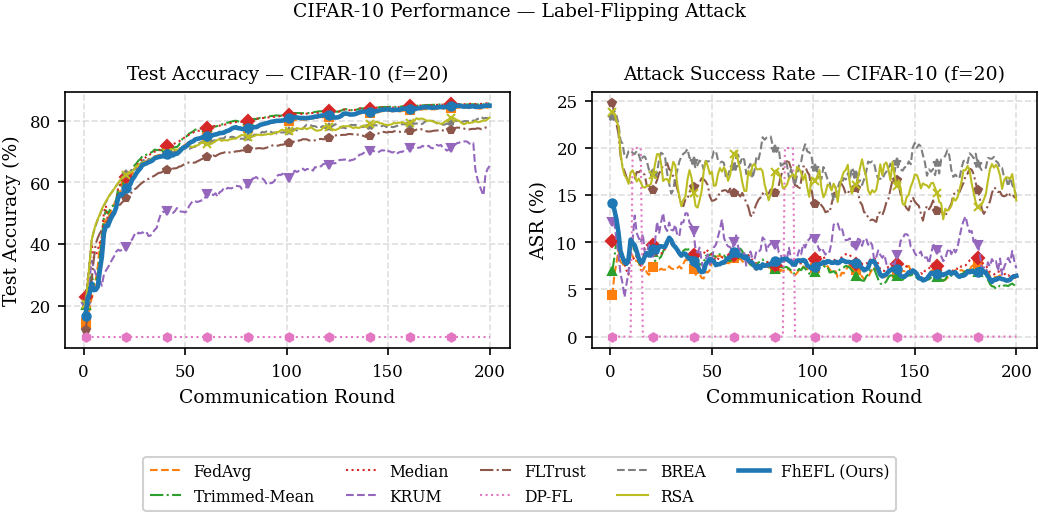

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(7.16, 2.8))
ax_acc, ax_asr = axs

for name, cfg in METHODS.items():
    acc = load(cfg["dir"], "accuracy_cifar_20.txt")
    if acc: ax_acc.plot(range(1,len(acc)+1), smooth(acc), color=cfg["color"],
                        ls=cfg["ls"], lw=cfg["lw"], label=name,
                        marker=cfg["marker"], markevery=20, markersize=4)
    asr = load(cfg["dir"], "asr_cifar_20.txt")
    if asr: ax_asr.plot(range(1,len(asr)+1), smooth(asr), color=cfg["color"],
                        ls=cfg["ls"], lw=cfg["lw"], label=name,
                        marker=cfg["marker"], markevery=20, markersize=4)

ax_acc.set_xlabel("Communication Round"); ax_acc.set_ylabel("Test Accuracy (%)")
ax_acc.set_title("Test Accuracy — CIFAR-10 (f=20)")
ax_asr.set_xlabel("Communication Round"); ax_asr.set_ylabel("ASR (%)")
ax_asr.set_title("Attack Success Rate — CIFAR-10 (f=20)")
fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5,-0.22), frameon=True)
fig.suptitle("CIFAR-10 Performance — Label-Flipping Attack", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_cifar10_label_flipping.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_cifar10_label_flipping.png")
plt.show()


## 8  CIFAR-100 Accuracy & ASR

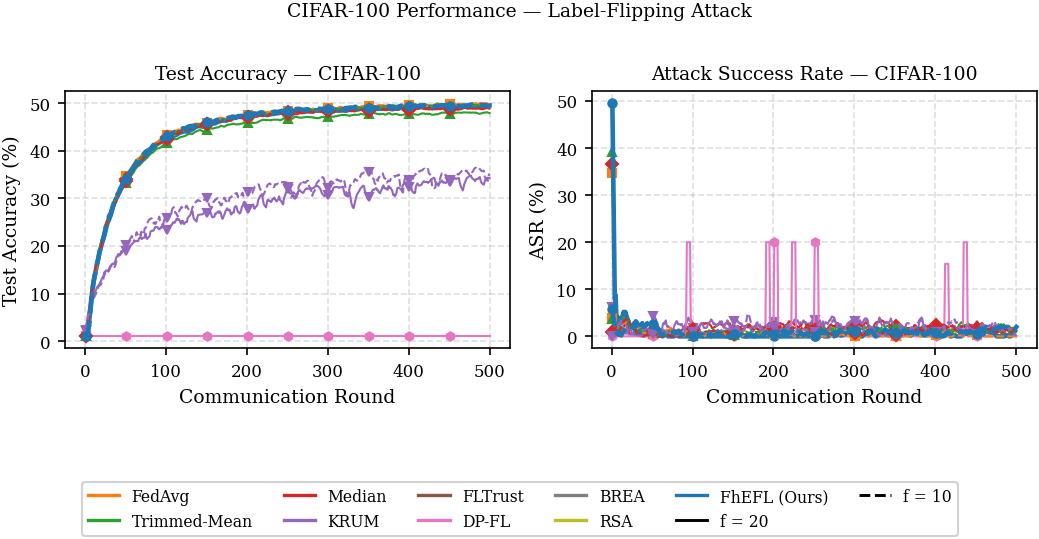

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(7.16, 2.8))
ax_acc, ax_asr = axs

for na, ls_o in [(20, "-"), (10, "--")]:
    for name, cfg in METHODS.items():
        acc = load(cfg["dir"], f"accuracy_cifar-100_{na}.txt")
        if acc:
            ax_acc.plot(range(1,len(acc)+1), smooth(acc), color=cfg["color"],
                        ls=ls_o, lw=cfg["lw"], label=f"{name} (f={na})",
                        marker=cfg["marker"], markevery=50, markersize=4)
        asr = load(cfg["dir"], f"asr_cifar-100_{na}.txt")
        if asr:
            ax_asr.plot(range(1,len(asr)+1), smooth(asr), color=cfg["color"],
                        ls=ls_o, lw=cfg["lw"],
                        marker=cfg["marker"], markevery=50, markersize=4)

ax_acc.set_xlabel("Communication Round"); ax_acc.set_ylabel("Test Accuracy (%)")
ax_acc.set_title("Test Accuracy — CIFAR-100")
ax_asr.set_xlabel("Communication Round"); ax_asr.set_ylabel("ASR (%)")
ax_asr.set_title("Attack Success Rate — CIFAR-100")
legend_items = (
    [Line2D([0],[0], color=METHODS[n]["color"], lw=1.6, label=n) for n in METHODS]
  + [Line2D([0],[0], color="k", ls="-",  lw=1.4, label="f = 20"),
     Line2D([0],[0], color="k", ls="--", lw=1.4, label="f = 10")]
)
fig.legend(handles=legend_items, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.28), frameon=True)
fig.suptitle("CIFAR-100 Performance — Label-Flipping Attack", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_cifar100_label_flipping.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_cifar100_label_flipping.png")
plt.show()


## 9  Model Poisoning — CIFAR-10

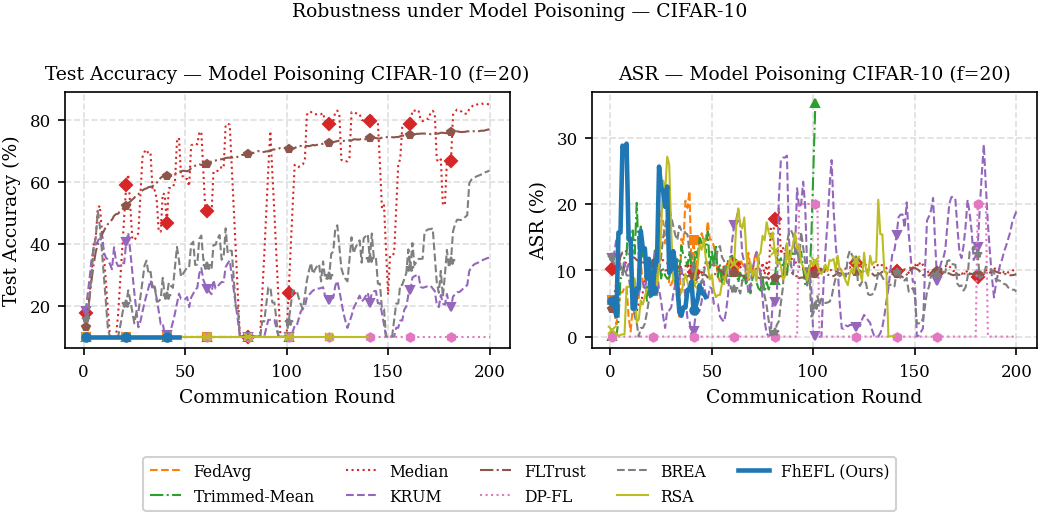

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(7.16, 2.8))
ax_acc, ax_asr = axs

for name, cfg in METHODS.items():
    acc = load(cfg["dir"], "accuracy_cifar_20_model_poisoning.txt")
    if acc: ax_acc.plot(range(1,len(acc)+1), smooth(acc), color=cfg["color"],
                        ls=cfg["ls"], lw=cfg["lw"], label=name,
                        marker=cfg["marker"], markevery=20, markersize=4)
    asr = load(cfg["dir"], "asr_cifar_20_model_poisoning.txt")
    if asr: ax_asr.plot(range(1,len(asr)+1), smooth(asr), color=cfg["color"],
                        ls=cfg["ls"], lw=cfg["lw"],
                        marker=cfg["marker"], markevery=20, markersize=4)

ax_acc.set_xlabel("Communication Round"); ax_acc.set_ylabel("Test Accuracy (%)")
ax_acc.set_title("Test Accuracy — Model Poisoning CIFAR-10 (f=20)")
ax_asr.set_xlabel("Communication Round"); ax_asr.set_ylabel("ASR (%)")
ax_asr.set_title("ASR — Model Poisoning CIFAR-10 (f=20)")
fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5,-0.22), frameon=True)
fig.suptitle("Robustness under Model Poisoning — CIFAR-10", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_model_poisoning_cifar10.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_model_poisoning_cifar10.png")
plt.show()


## 10  Radar Chart — Overall Robustness Profile

In [ ]:
# Radar chart: each axis = one (dataset, attack, metric) combo
# Higher = better for accuracy; lower = better for ASR → invert ASR
RADAR_AXES = [
    ("MNIST
Acc (LF f=20)",  "accuracy_mnist_20.txt",             True),
    ("CIFAR-10
Acc (LF f=20)","accuracy_cifar_20.txt",            True),
    ("CIFAR-100
Acc (LF f=20)","accuracy_cifar-100_20.txt",       True),
    ("MNIST
Acc (MP f=20)",  "accuracy_mnist_20_model_poisoning.txt", True),
    ("MNIST
ASR low (LF f=20)", "asr_mnist_20.txt",               False),
    ("MNIST
ASR low (MP f=20)", "asr_mnist_20_model_poisoning.txt",False),
]
N = len(RADAR_AXES)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(4.5, 4.5), subplot_kw=dict(polar=True))

for name, cfg in METHODS.items():
    vals = []
    for _, fname, higher_is_better in RADAR_AXES:
        v = final_val(cfg["dir"], fname, last_n=10)
        if np.isnan(v):
            vals.append(float("nan"))
            continue
        # normalise to [0,1]: higher_is_better → v/100; else → 1 - v/100
        vals.append(v/100 if higher_is_better else 1 - v/100)
    if all(np.isnan(vals)):
        continue
    vals_closed = vals + [vals[0]]
    ax.plot(angles, vals_closed, color=cfg["color"], ls=cfg["ls"],
            lw=cfg["lw"], label=name)
    ax.fill(angles, vals_closed, color=cfg["color"], alpha=0.06)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([a[0] for a in RADAR_AXES], size=7.5)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], size=6.5)
ax.set_title("Robustness Radar (higher = better on all axes)", size=9, pad=14)
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), fontsize=7)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_radar_robustness.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_radar_robustness.png")
plt.show()

SyntaxError: EOL while scanning string literal (3451457031.py, line 4)

## 11  Summary Table

In [ ]:
import pandas as pd

rows = []
for name, cfg in METHODS.items():
    row = {"Method": name}
    row["MNIST Acc (LF f=20)"]  = f"{final_val(cfg["dir"], "accuracy_mnist_20.txt"):.1f}"
    row["MNIST ASR (LF f=20)"]  = f"{final_val(cfg["dir"], "asr_mnist_20.txt"):.1f}"
    row["MNIST Acc (LF f=5)"]   = f"{final_val(cfg["dir"], "accuracy_mnist_5.txt"):.1f}"
    row["CIFAR-10 Acc (f=20)"]  = f"{final_val(cfg["dir"], "accuracy_cifar_20.txt"):.1f}"
    row["CIFAR-10 ASR (f=20)"]  = f"{final_val(cfg["dir"], "asr_cifar_20.txt"):.1f}"
    row["CIFAR-100 Acc (f=20)"] = f"{final_val(cfg["dir"], "accuracy_cifar-100_20.txt"):.1f}"
    row["MNIST Acc (MP f=20)"]  = f"{final_val(cfg["dir"], "accuracy_mnist_20_model_poisoning.txt"):.1f}"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Method")
df.replace("nan", "—", inplace=True)
display(df)
df.to_csv(f"{PLOTS_DIR}/summary_table.csv")
print("Latex:")
print(df.to_latex())


SyntaxError: invalid syntax (1908511674.py, line 6)